In [1]:
import triangle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from collections import defaultdict
from shapely.geometry import Point, Polygon, LineString


In [2]:
def cast_rays_with_holes(polygon, viewpoint, n_rays=500):
    ray_points = []
    angles = np.linspace(0, 2 * np.pi, n_rays)

    # Extract exterior and holes
    edges = []
    coords = list(polygon.exterior.coords)
    edges.extend(zip(coords[:-1], coords[1:]))

    for interior in polygon.interiors:
        coords = list(interior.coords)
        edges.extend(zip(coords[:-1], coords[1:]))

    for angle in angles:
        dx, dy = np.cos(angle), np.sin(angle)
        far_point = (viewpoint[0] + dx * 1000, viewpoint[1] + dy * 1000)
        ray = LineString([viewpoint, far_point])
        min_dist = float('inf')
        closest_pt = None
        for seg_start, seg_end in edges:
            edge = LineString([seg_start, seg_end])
            if ray.intersects(edge):
                pt = ray.intersection(edge)
                if isinstance(pt, Point):
                    dist = Point(viewpoint).distance(pt)
                    if dist < min_dist:
                        min_dist = dist
                        closest_pt = pt
        if closest_pt:
            ray_points.append((closest_pt.x, closest_pt.y))
    return ray_points


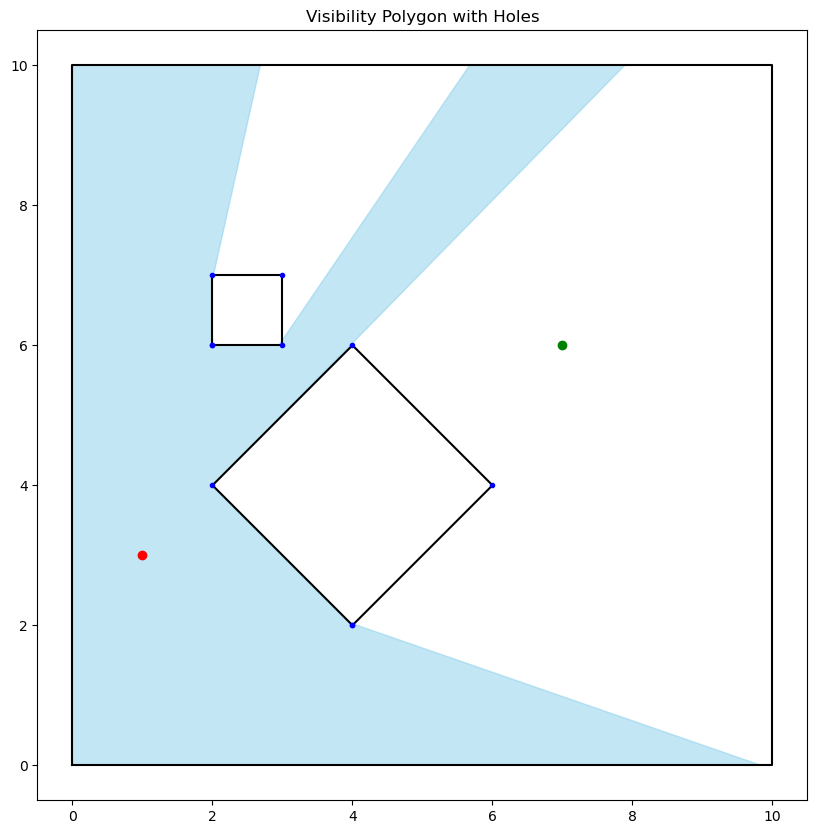

In [3]:
# Define outer polygon and hole
outer = [(0,0), (10,0), (10,10), (0,10)]
holes = [[(4,2), (6,4), (4,6), (2,4)],
        [(2,6), (3,6), (3,7), (2,7)]]

polygon = Polygon(outer, holes)
viewpoint = (1,3)
destination = [7, 6]

# Compute visibility
vis_points = cast_rays_with_holes(polygon, viewpoint)
vis_polygon = Polygon(vis_points)

# Plotting
fig, ax = plt.subplots(figsize=(10,10))
ox, oy = zip(*polygon.exterior.coords)
ax.plot(ox, oy, 'k-', label='Outer Boundary')

for interior in polygon.interiors:
    hx, hy = zip(*interior.coords)
    ax.plot(hx, hy, 'k-', label='Hole')
    ax.plot(hx, hy, 'b.', label='Vertices')    

vx, vy = zip(*vis_polygon.exterior.coords)
ax.fill(vx, vy, color='skyblue', alpha=0.5, label='Visibility')
ax.plot(*viewpoint, 'ro', label='Viewpoint')
ax.plot(destination[0], destination[1], 'go')
ax.set_aspect('equal')
plt.title("Visibility Polygon with Holes")
#plt.legend()
plt.show()

In [4]:
# Combine all points
points = outer + [vert for hole in holes for vert in hole]

# Define segments (edges) for outer boundary
segments_outer = [[i, (i + 1) % len(outer)] for i in range(len(outer))]

# Define segments for hole (offset by len(outer))
offset = len(outer)
segments_holes = []
for hole in holes:
    segments_holes += [(offset + i, offset + (i + 1) % len(hole)) for i in range(len(hole))]
    offset += len(hole)

In [5]:
points

[(0, 0),
 (10, 0),
 (10, 10),
 (0, 10),
 (4, 2),
 (6, 4),
 (4, 6),
 (2, 4),
 (2, 6),
 (3, 6),
 (3, 7),
 (2, 7)]

In [6]:
segments_holes

[(4, 5), (5, 6), (6, 7), (7, 4), (8, 9), (9, 10), (10, 11), (11, 8)]

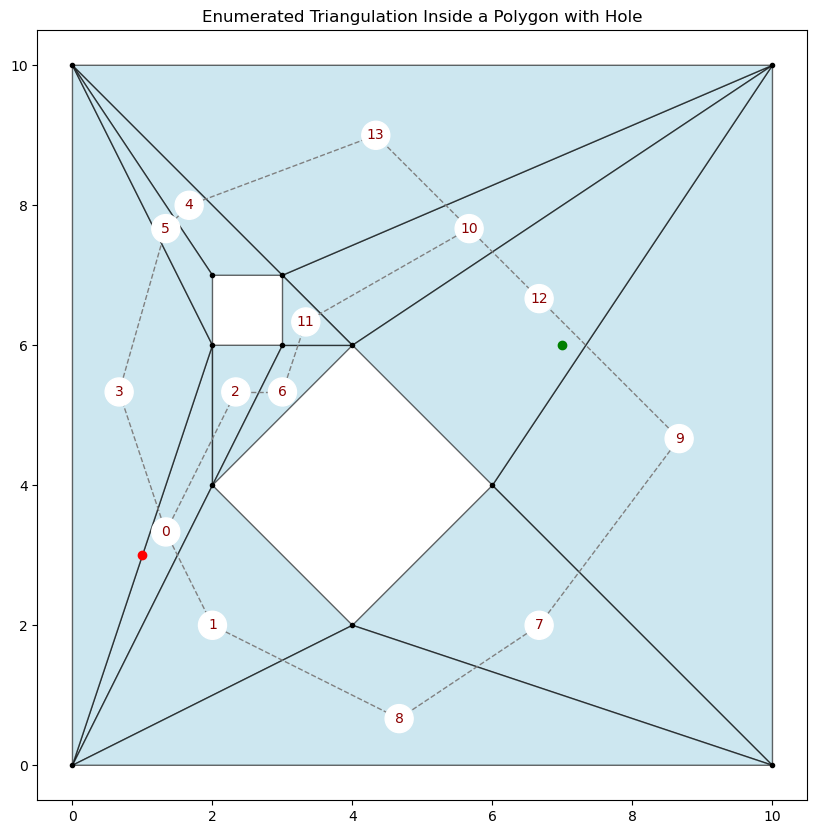

In [7]:
# Combine all segments
segments = segments_outer + segments_holes

# Define a point inside the hole to mark it
hole_points = [(4, 4), (2.5, 6.5)]

# Prepare input for triangle
A = {
    'vertices': points,
    'segments': segments,
    'holes': hole_points
}

# Triangulate with 'p' for PSLG
B = triangle.triangulate(A, 'p')

# Compute centroids
centroids = [np.mean(B['vertices'][tri], axis=0) for tri in B['triangles']]

# Build adjacency map
adjacency = defaultdict(set)
triangles = B['triangles']
for i, tri_i in enumerate(triangles):
    edges_i = {frozenset((tri_i[j], tri_i[(j + 1) % 3])) for j in range(3)}
    for j in range(i + 1, len(triangles)):
        tri_j = triangles[j]
        edges_j = {frozenset((tri_j[k], tri_j[(k + 1) % 3])) for k in range(3)}
        if edges_i & edges_j:
            adjacency[i].add(j)
            adjacency[j].add(i)

# Prepare connection pairs
connections = [(i, j) for i, neighbors in adjacency.items() for j in neighbors if i < j]

# Plot manually using matplotlib
plt.figure(figsize=(10, 10))
for i, tri in enumerate(B['triangles']):
    pts = B['vertices'][tri]
    polygon = plt.Polygon(pts, edgecolor='black', facecolor='lightblue', alpha=0.6)
    plt.gca().add_patch(polygon)
    # Compute centroid
    centroid = np.mean(pts, axis=0)

    # Add white circle background
    circle = patches.Circle(centroid, radius=0.2, color='white', zorder=3)
    plt.gca().add_patch(circle)

    # Add triangle index text
    plt.text(centroid[0], centroid[1], str(i), ha='center', va='center',
             fontsize=10, color='darkred', zorder=4)

# Draw dashed lines between adjacent centroids
for i, neighbors in adjacency.items():
    for j in neighbors:
        if i < j:  # Avoid duplicate lines
            x_vals = [centroids[i][0], centroids[j][0]]
            y_vals = [centroids[i][1], centroids[j][1]]
            plt.plot(x_vals, y_vals, linestyle='--', color='gray', linewidth=1, zorder=2)


# Plot vertices
x, y = zip(*B['vertices'])
plt.plot(x, y, 'ko', markersize=3)
plt.plot(*viewpoint, 'ro', label='Viewpoint')
plt.plot(destination[0], destination[1], 'go')

plt.gca().set_aspect('equal')
plt.title("Linked Triangulation Inside a Polygon with Hole")
plt.show()

In [8]:
B


{'vertices': array([[ 0.,  0.],
        [10.,  0.],
        [10., 10.],
        [ 0., 10.],
        [ 4.,  2.],
        [ 6.,  4.],
        [ 4.,  6.],
        [ 2.,  4.],
        [ 2.,  6.],
        [ 3.,  6.],
        [ 3.,  7.],
        [ 2.,  7.]]),
 'vertex_markers': array([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1]], dtype=int32),
 'triangles': array([[ 0,  7,  8],
        [ 7,  0,  4],
        [ 8,  7,  9],
        [ 0,  8,  3],
        [10,  3, 11],
        [11,  3,  8],
        [ 7,  6,  9],
        [ 4,  1,  5],
        [ 1,  4,  0],
        [ 5,  1,  2],
        [10,  6,  2],
        [10,  9,  6],
        [ 2,  6,  5],
        [10,  2,  3]], dtype=int32),
 'segments': array([[ 1,  0],
        [ 2,  1],
        [ 3,  2],
        [ 0,  3],
        [ 5,  4],
        [ 5,  6],
        [ 7,  6],
        [ 4,  7],
        [ 9,  8],
        [ 9, 10],
        [10, 11],
        [ 8